# Reproduction of Arleo & Peigne d+Au 200 GeV (Figures 3 & 4)

In [1]:
# ==============================================================================
# d+Au 200 GeV Analysis (Arleo & Peigne Reproduction)
# ==============================================================================
import sys, os
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import replace

# Add library path
sys.path.append("../eloss_code")

# Global plot styling
plt.rcParams.update({
    "figure.dpi": 150,
    "figure.figsize": (6, 4),
    "axes.grid": False,
    "axes.labelsize": 12,
    "axes.titlesize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10
})

# --- Imports from our libraries ---
import eloss_cronin_dAu as EDA
import quenching_fast as QF
from particle import Particle, PPSpectrumParams
from coupling  import alpha_s_provider

print("Imports successful.")


Imports successful.


In [2]:
### 1. Setup System
root_s = 200.0   # GeV
A_Au   = 197

# 2. Particle (J/psi at RHIC 200 GeV)
# Parameters from Arleo & Peigne Table 1 (User provided image)
# p0 = 3.3 GeV, n = 8.3, m = 4.3
pp_rhic = PPSpectrumParams(p0=3.3, m=4.3, n=8.3) 

P_psi = Particle(family="charmonia", state="avg", pp_params=pp_rhic)

print(f"Particle: J/psi (RHIC params: p0={P_psi.pp.p0}, m={P_psi.pp.m}, n={P_psi.pp.n})")

# 3. Quenching Parameters (Arleo-Peigne Standard)
alpha_cst = alpha_s_provider(mode="constant", alpha0=0.5)

qp_base = QF.QuenchParams(
    qhat0=0.075,        # GeV^2/fm
    lp_fm=1.5,          # fm (coherence length)
    LA_fm=0.0,          # Placeholder, set dynamically
    LB_fm=0.0,          # Placeholder
    lambdaQCD=0.25,
    roots_GeV=root_s,
    alpha_of_mu=alpha_cst,
    alpha_scale="mT",
    use_hard_cronin=True,
    mapping="exp",
    device="cuda" if QF._HAS_TORCH and QF.torch.cuda.is_available() else "cpu"
)

# 4. Centrality Classes and L_eff
# Exact values requested by user
LEFF_DICT_CENT = {
    "0-20%":   12.87,
    "20-40%":  9.62,
    "40-60%":  7.17,
    "60-88%":  3.84
}

LEFF_DICT_MB = {
    "MinBias": 10.23 # Arleo Peigne Page 5, L_Au = 10.23 fm
}

# 5. Rapidity Windows (PHENIX)
# Using exact mid-points
# Backward (-2.2, -1.2) -> -1.7
# Central (-0.35, 0.35) -> 0.0
# Forward (1.2, 2.2)    -> 1.7
RAP_WINDOWS = {
    "Backward": -1.7, 
    "Central":  0.0,  
    "Forward":  1.7   
}

pT_grid = np.linspace(0.0, 15.0, 50)

print(f"System: d+Au {root_s} GeV")
print(f"Device: {qp_base.device}")
print("Centrality L_eff values:", LEFF_DICT_CENT)


Particle: J/psi (RHIC params: p0=3.3, m=4.3, n=8.3)
System: d+Au 200.0 GeV
Device: cuda
Centrality L_eff values: {'0-20%': 12.87, '20-40%': 9.62, '40-60%': 7.17, '60-88%': 3.84}


Computing for Backward (y=-1.7)...
Computing for Central (y=0.0)...
Computing for Forward (y=1.7)...


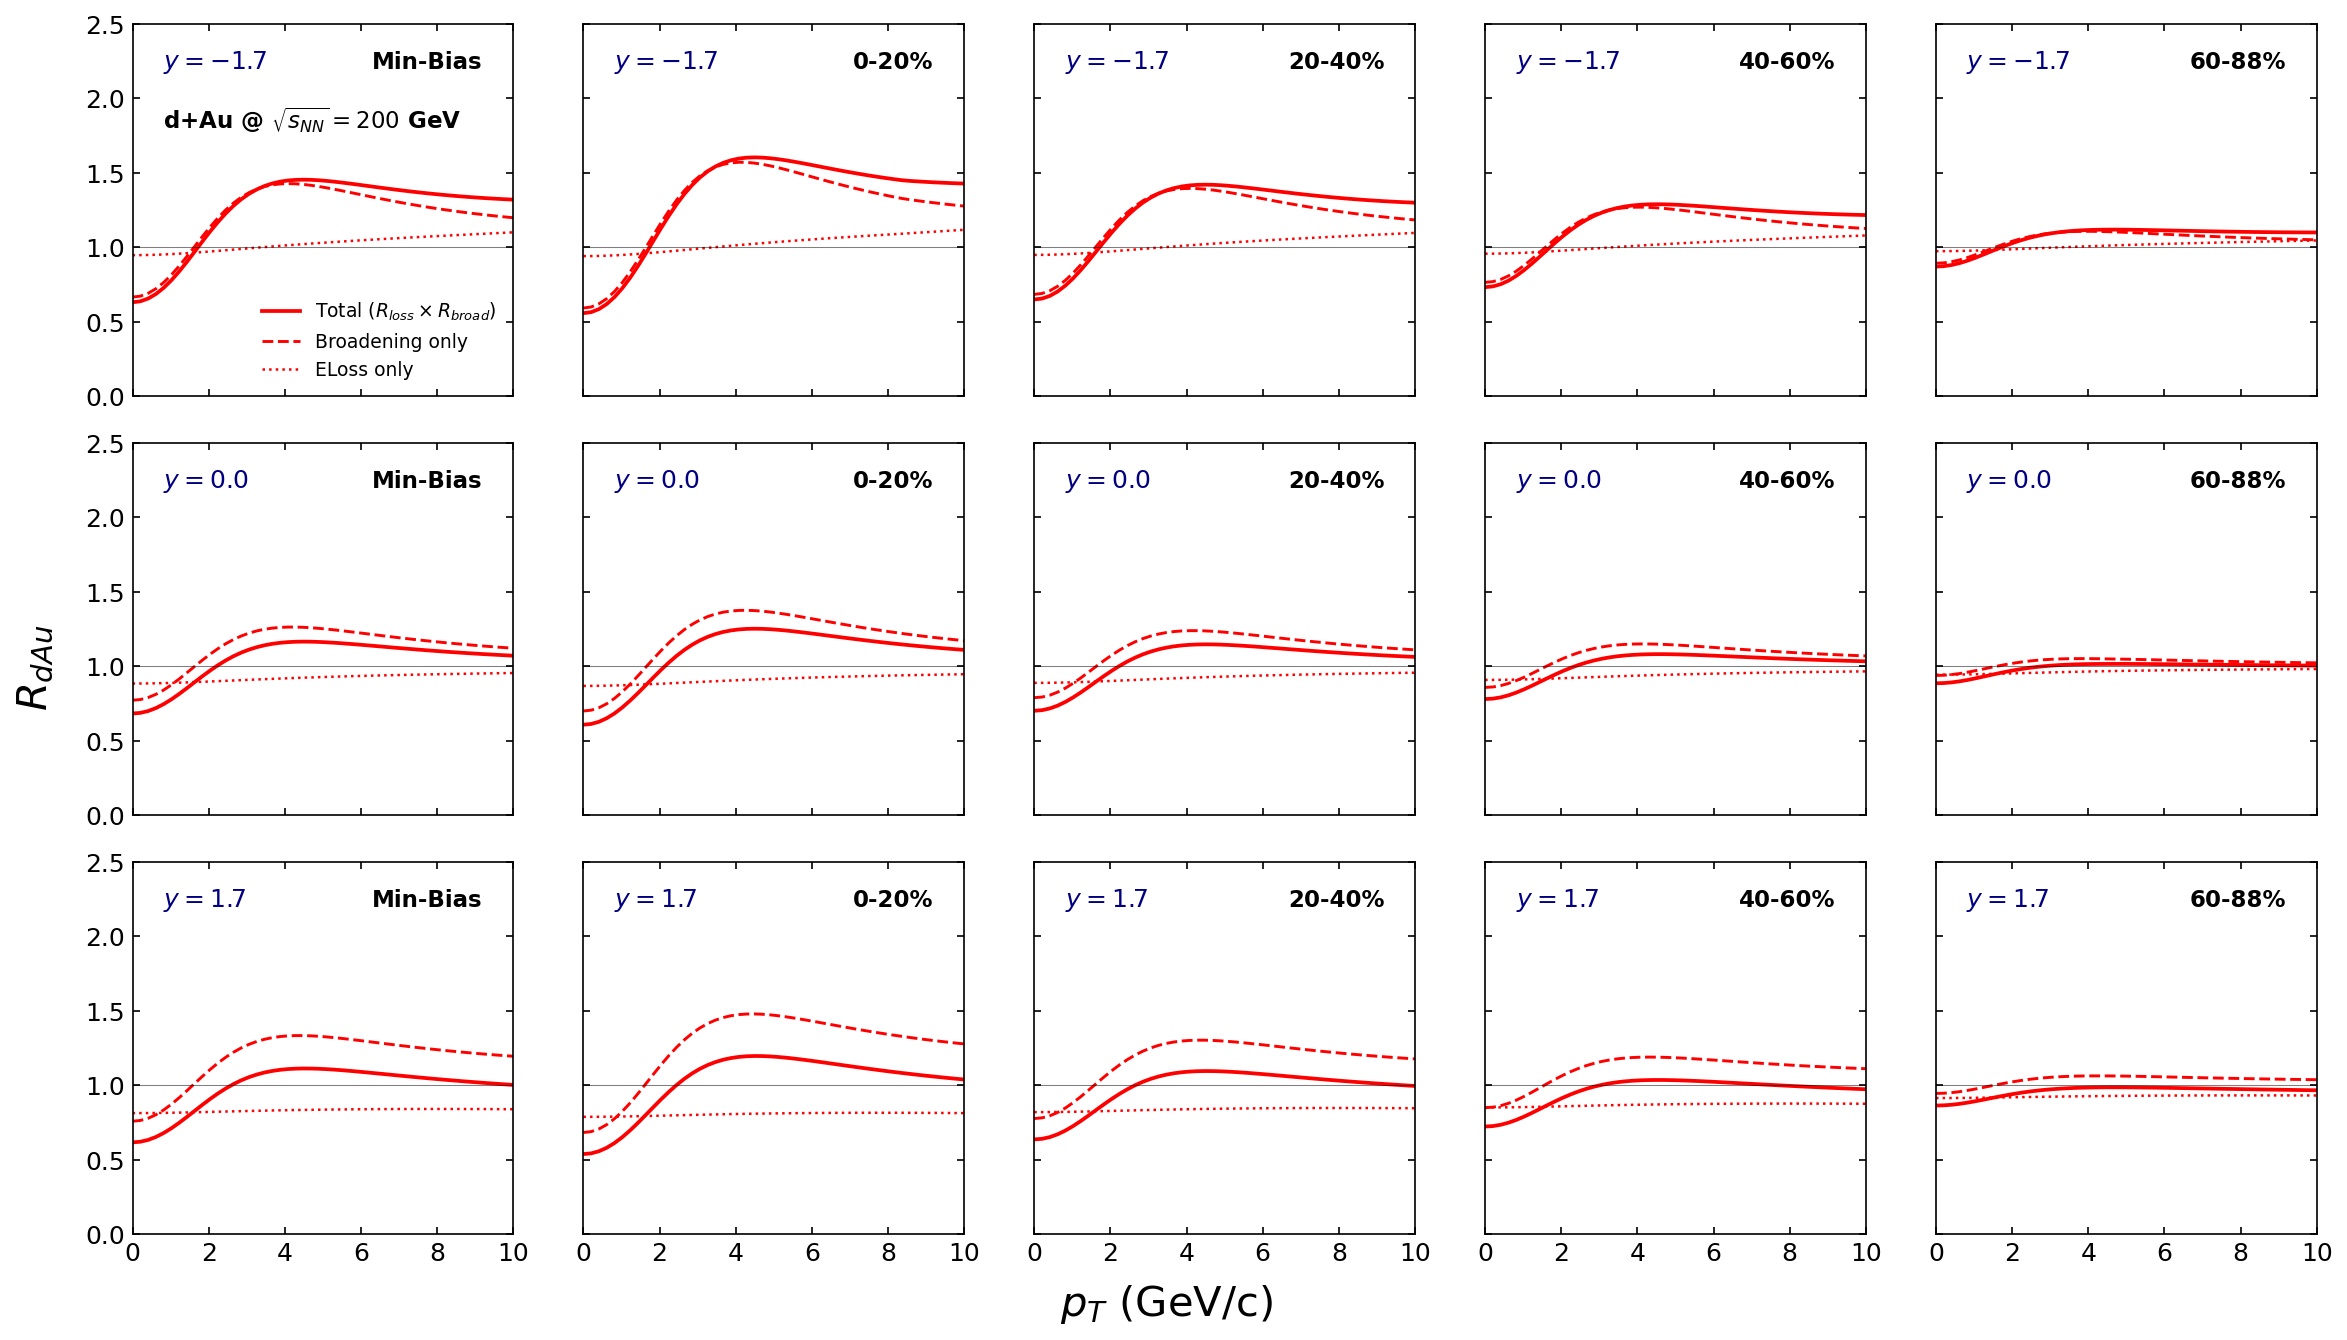

In [3]:
# Compute Curves
results = {}
pT_grid = np.linspace(0, 10, 50) # Assuming pT_grid is defined

for rap_label, y_val in RAP_WINDOWS.items():
    print(f"Computing for {rap_label} (y={y_val})...")
    
    # 1. Centralities
    res_cent = EDA.curves_vs_pT(
        P=P_psi, roots_GeV=root_s, qp_base=qp_base, 
        Leff_dict=LEFF_DICT_CENT, pT_grid=pT_grid, y_fix=float(y_val)
    )
    
    # 2. MinBias
    res_mb = EDA.curves_vs_pT(
        P=P_psi, roots_GeV=root_s, qp_base=qp_base, 
        Leff_dict=LEFF_DICT_MB, pT_grid=pT_grid, y_fix=float(y_val)
    )
    
    results[rap_label] = {"cent": res_cent, "mb": res_mb}
    
import matplotlib.pyplot as plt

# --- SETTINGS KNOBS ---
SHOW_Y_EVERYWHERE = True   
SHOW_SYSTEM_INSIDE = True  
# ----------------------

col_order = ["MinBias", "0-20%", "20-40%", "40-60%", "60-88%"]
rap_order = ["Backward", "Central", "Forward"]
RAP_VALS = {"Backward": "-1.7", "Central": "0.0", "Forward": "1.7"}

fig, axes = plt.subplots(3, 5, figsize=(16, 9), sharex=True, sharey=True)
plt.subplots_adjust(wspace=0, hspace=0) 

for r_idx, rap in enumerate(rap_order):
    y_val = RAP_VALS[rap]
    
    for c_idx, col_name in enumerate(col_order):
        ax = axes[r_idx, c_idx]
        
        # Data Selection
        if col_name == "MinBias":
            data_source = results[rap].get("mb", {}).get("MinBias")
            display_name = "Min-Bias"
        else:
            data_source = results[rap].get("cent", {}).get(col_name)
            display_name = col_name

        # Plotting
        if data_source:
            rl, rb, rt = data_source 
            ax.plot(pT_grid, rt, color="red", ls="-", lw=1.8, label="Total ($R_{loss} \\times R_{broad}$)")
            ax.plot(pT_grid, rb, color="red", ls="--", lw=1.4, label="Broadening only")
            ax.plot(pT_grid, rl, color="red", ls=":", lw=1.2, label="ELoss only") # Added ELoss component
        
        # Style basics
        ax.axhline(1.0, color="black", ls="-", lw=0.5, alpha=0.5)
        ax.set_xlim(0, 10)
        ax.set_ylim(0, 2.5) 
        ax.tick_params(axis='both', which='both', direction='in', top=True, right=True, labelsize=12)

        # --- INTERNAL ANNOTATIONS ---
        if SHOW_SYSTEM_INSIDE and r_idx == 0 and c_idx == 0:
            ax.text(0.08, 0.72, r"d+Au @ $\sqrt{s_{NN}}=200$ GeV", 
                    transform=ax.transAxes, fontsize=11, fontweight='bold', color='black')
        
        if SHOW_Y_EVERYWHERE or (c_idx == 0):
            ax.text(0.08, 0.88, f"$y = {y_val}$", transform=ax.transAxes, 
                    fontsize=12, fontweight='bold', color='navy')
        
        ax.text(0.92, 0.88, display_name, transform=ax.transAxes, 
                ha='right', fontsize=11, fontweight='semibold')

        if r_idx == 0 and c_idx == 0:
            ax.legend(frameon=False, fontsize=9, loc="lower right")

# Global Axis Labels
fig.text(0.5, 0.02, r'$p_T$ (GeV/c)', ha='center', fontsize=20)
fig.text(0.02, 0.5, r'$R_{dAu}$', va='center', rotation='vertical', fontsize=20)

plt.tight_layout(rect=[0.04, 0.04, 1, 1])
plt.show()

In [4]:
# 1. Define Rapidity Windows (Exact ranges from PHENIX/Arleo-Peigne)
RAP_WINDOW_BINS = {
    "Backward": (-2.2, -1.2),
    "Central":  (-0.35, 0.35),
    "Forward":  (1.2, 2.2)
}
# 2. Compute Binned Results with two-sided (mode="AB") logic
results_binned = {}
for rap_label, y_range in RAP_WINDOW_BINS.items():
    print(f"Computing binned averages for {rap_label} ({y_range})...")
    
    # Centralities
    res_cent = EDA.curves_vs_pT_binned_rap(
        P=P_psi, roots_GeV=root_s, qp_base=qp_base, 
        Leff_dict=LEFF_DICT_CENT, pT_grid=pT_grid, y_range=y_range, mode="AB"
    )
    
    # MinBias
    res_mb = EDA.curves_vs_pT_binned_rap(
        P=P_psi, roots_GeV=root_s, qp_base=qp_base, 
        Leff_dict=LEFF_DICT_MB, pT_grid=pT_grid, y_range=y_range, mode="AB"
    )
    
    results_binned[rap_label] = {"cent": res_cent, "mb": res_mb}

Computing binned averages for Backward ((-2.2, -1.2))...
Computing binned averages for Central ((-0.35, 0.35))...
Computing binned averages for Forward ((1.2, 2.2))...


Computing Backward [-2.20, -1.20]...
Computing Central [-0.35, 0.35]...
Computing Forward [1.20, 2.20]...


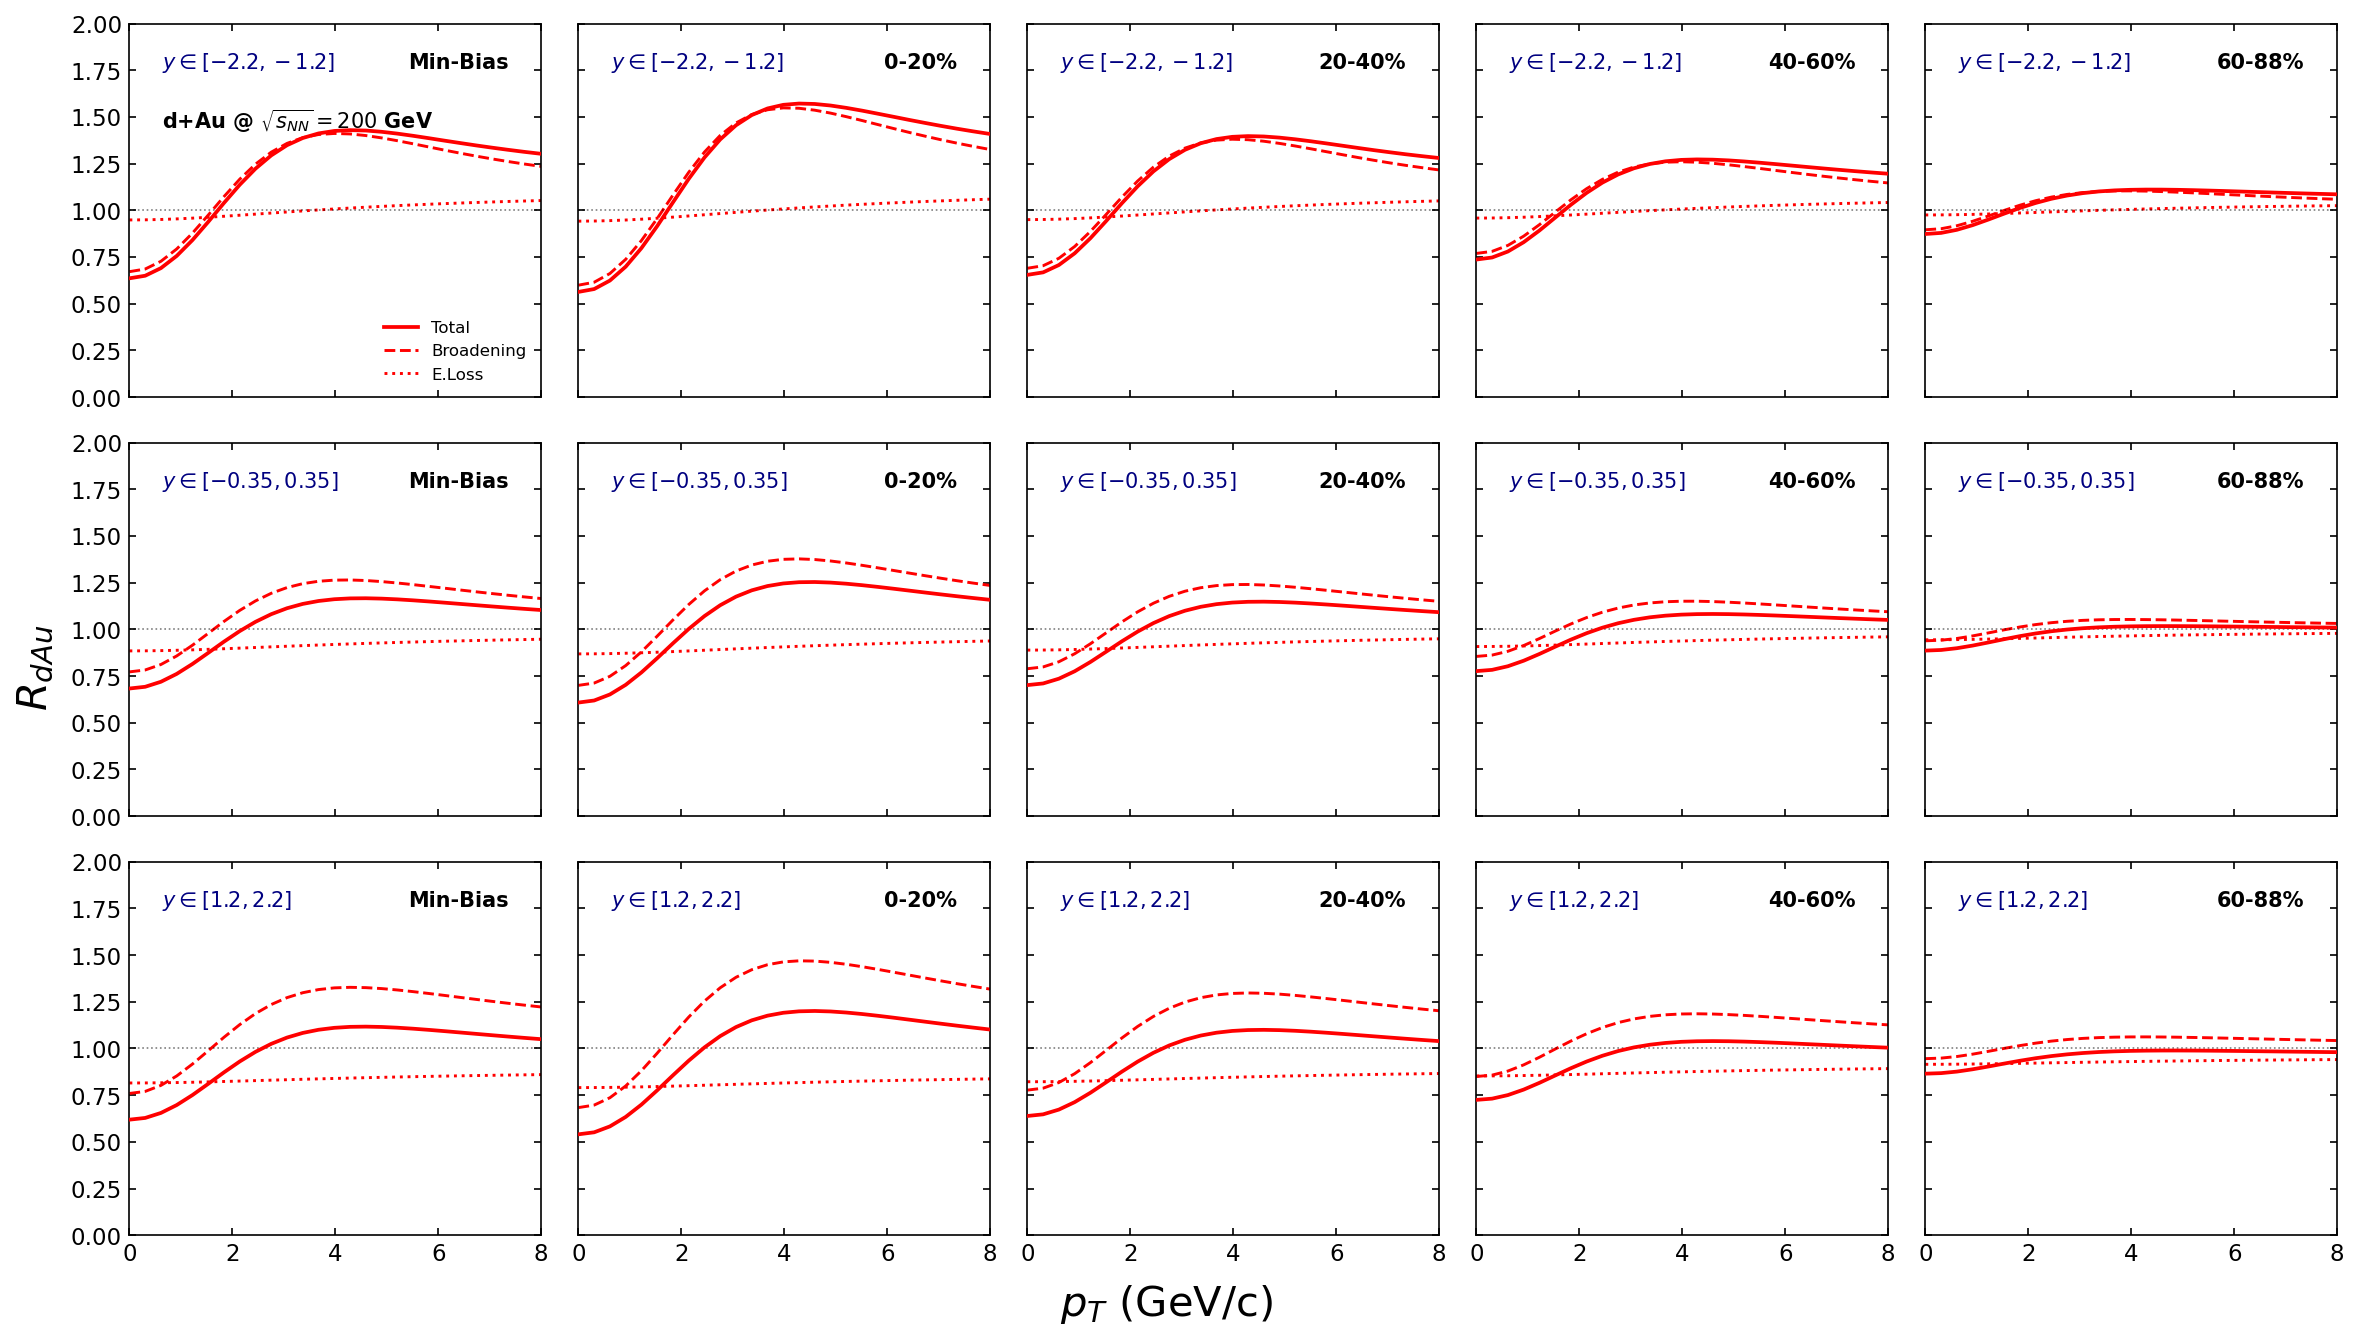

In [5]:
# L_eff from Arleo-Peigné page 5
LEFF_DICT_MB = {"MinBias": 10.23}
LEFF_DICT_CENT = {
    "0-20%": 12.87, "20-40%": 9.62,
    "40-60%": 7.17, "60-88%": 3.84
}
pT_grid = np.linspace(0.0, 15.0, 50)
# ==============================================================================
# CELL 3: Binned Computation (Reproduces Arleo-Peigné Figure 3)
# ==============================================================================
RAP_WINDOW_BINS = {
    "Backward": (-2.2, -1.2),
    "Central":  (-0.35, 0.35),
    "Forward":  (1.2, 2.2)
}
results_binned = {}
for rap_label, y_range in RAP_WINDOW_BINS.items():
    print(f"Computing {rap_label} [{y_range[0]:.2f}, {y_range[1]:.2f}]...")
    
    res_cent = EDA.curves_vs_pT_binned_rap(
        P=P_psi, roots_GeV=root_s, qp_base=qp_base, 
        Leff_dict=LEFF_DICT_CENT, pT_grid=pT_grid, 
        y_range=y_range, mode="AB"  # Two-sided for d+Au
    )
    
    res_mb = EDA.curves_vs_pT_binned_rap(
        P=P_psi, roots_GeV=root_s, qp_base=qp_base, 
        Leff_dict=LEFF_DICT_MB, pT_grid=pT_grid, 
        y_range=y_range, mode="AB"
    )
    
    results_binned[rap_label] = {"cent": res_cent, "mb": res_mb}
# ==============================================================================
# CELL 4: Plot with ALL THREE components (rl, rb, rt)
# ==============================================================================
col_order = ["MinBias", "0-20%", "20-40%", "40-60%", "60-88%"]
rap_order = ["Backward", "Central", "Forward"]
RAP_STR = {
    "Backward": "[-2.2, -1.2]", 
    "Central": "[-0.35, 0.35]", 
    "Forward": "[1.2, 2.2]"
}
fig, axes = plt.subplots(3, 5, figsize=(16, 9), sharex=True, sharey=True)
plt.subplots_adjust(wspace=0, hspace=0) 
for r_idx, rap in enumerate(rap_order):
    for c_idx, col_name in enumerate(col_order):
        ax = axes[r_idx, c_idx]
        
        if col_name == "MinBias":
            data = results_binned[rap]["mb"].get("MinBias")
            display = "Min-Bias"
        else:
            data = results_binned[rap]["cent"].get(col_name)
            display = col_name
        if data:
            rl, rb, rt = data
            # Plot ALL THREE curves
            ax.plot(pT_grid, rt, 'r-', lw=1.8, label="Total", zorder=3)
            ax.plot(pT_grid, rb, 'r--', lw=1.4, label="Broadening", zorder=2)
            ax.plot(pT_grid, rl, 'r:', lw=1.4, label="E.Loss", zorder=1)
        
        ax.axhline(1.0, color='k', ls=':', lw=0.8, alpha=0.5)
        ax.set_xlim(0, 8)
        ax.set_ylim(0, 2.0)
        ax.tick_params(axis='both', which='both', direction='in', 
                        top=True, right=True, labelsize=11)
        if r_idx == 0 and c_idx == 0:
            ax.text(0.08, 0.72, r"d+Au @ $\sqrt{s_{NN}}=200$ GeV", 
                    transform=ax.transAxes, fontsize=10, fontweight='bold')
            ax.legend(frameon=False, loc="lower right", fontsize=8)
        
        ax.text(0.08, 0.88, f"$y\\in{RAP_STR[rap]}$", 
                transform=ax.transAxes, fontsize=10, fontweight='bold', color='navy')
        ax.text(0.92, 0.88, display, transform=ax.transAxes, 
                ha='right', fontsize=10, fontweight='semibold')
fig.text(0.5, 0.02, r'$p_T$ (GeV/c)', ha='center', fontsize=20)
fig.text(0.02, 0.5, r'$R_{dAu}$', va='center', rotation='vertical', fontsize=20)
plt.tight_layout(rect=[0.04, 0.04, 1, 1])
plt.show()